In [11]:
##### Cleans irrigation data from Mehta et al (2024) 
# loads and 

import os
import pandas as pd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import CRS, Transformer

In [16]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# set raster path
raster_path = f'{cd}/Data/Raw/Predictors/Field_size_Lesiv/dominant_field_size_categories.tif'

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 65535.0, 'width': 62781, 'height': 23020, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.00538989170465242, 0.0, -159.83238760108304,
       0.0, -0.00538989170465242, 69.99987104207773), 'blockxsize': 128, 'blockysize': 128, 'tiled': True, 'compress': 'lzw', 'interleave': 'band'}


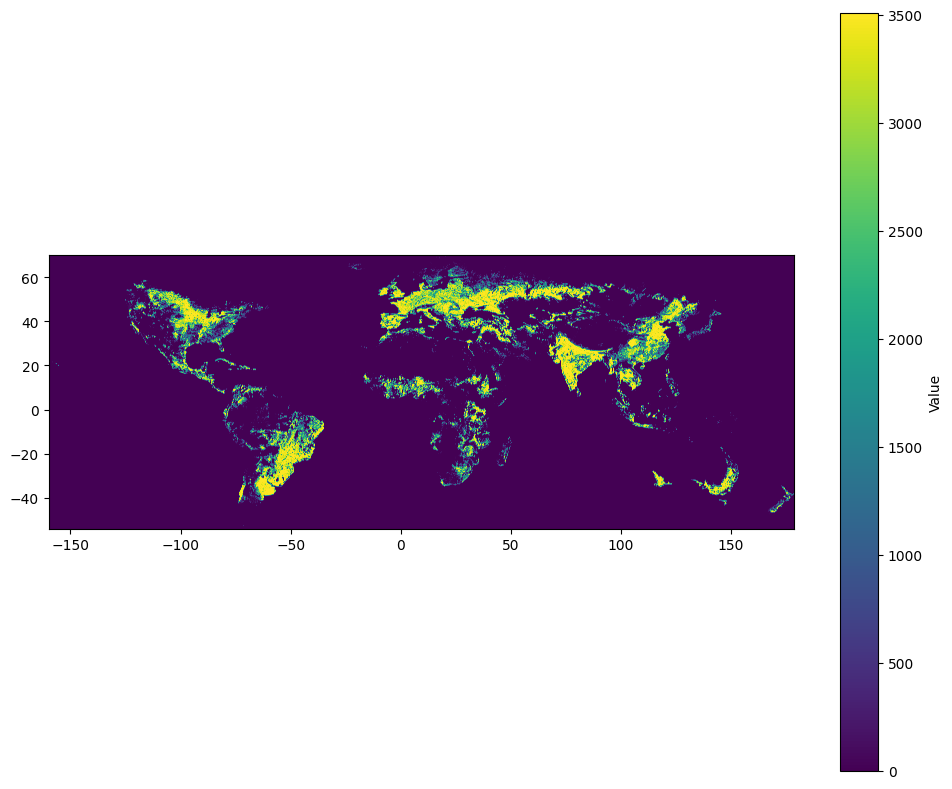

In [18]:
#### Map raster

with rasterio.open(raster_path) as src:
    data = src.read(1)          
    nodata = src.nodata         
    profile = src.profile       
    extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]

print(profile)

# Mask no data
if nodata is not None:
    masked = np.where(data == nodata, np.nan, data)
else:
    masked = data.astype(float)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    masked,
    extent=extent,
    cmap="viridis",
    origin="upper"
)

plt.colorbar(im, ax=ax, label="Value")

plt.tight_layout()
plt.show()

In [7]:
# #### Get global sum of raster
# total_sum = np.nansum(masked)
# print(f"Total Sum: {total_sum:,.4f}")

Total Sum: 329,539,872.0000
